## EDA 

In [ ]:
import pandas as pd
from pathlib import Path
import matplotlib.pyplot as plt
import matplotlib.ticker as mticker

proyecto_root = Path.cwd().parent
ruta_csv = proyecto_root / "data" / "df_modelo_para_tarifacion.csv"

df_eda = pd.read_csv(ruta_csv)
print(df_eda.shape)
df_eda.head()

(260853, 32)


,Afiliado_Id,FechaNacimiento_dt,edad,grupo_edad,CIUDAD_NORM,Sexo_Cd_limpio,CANCER,DIABETES,ENF_CARDIACA,HIPERTENSION,...,rec_CONSULTAS,rec_EXAMENES MEDICOS,rec_HOSPITALIZACIONES COMPLEJAS,rec_HOSPITALIZACIONES SIMPLES,rec_LABORATORIO,rec_TRATAMIENTO DE CANCER,en_exposicion,en_siniestros,categoria_cobertura,sin_exposicion_match
0,921437,1968-04-30,57,46-60,MEDELLIN,F,0,0,0,0,...,0,1,0,0,0,0,1,1,Completo (Exp + Sin),0
1,60504878,2012-02-18,14,0-17,MEDELLIN,M,0,0,0,0,...,0,0,0,1,0,0,1,1,Completo (Exp + Sin),0
2,55074222,2014-10-23,11,0-17,MEDELLIN,F,0,0,0,0,...,0,4,1,1,0,0,1,1,Completo (Exp + Sin),0
3,23690690,1989-06-27,36,31-45,CARTAGENA,F,0,0,0,0,...,0,4,0,0,0,0,1,1,Completo (Exp + Sin),0
4,45506882,2009-06-30,16,0-17,CALI,M,0,0,0,0,...,0,1,0,1,0,0,1,1,Completo (Exp + Sin),0


In [14]:
# 1) Número total de variables
print("N° de variables:", len(df_eda.columns))

# 2) Lista completa de nombres
print(df_eda.columns.tolist())

# 3) Tabla ordenada de variables (más legible)
display(
    pd.DataFrame({
        "variable": df_eda.columns,
        "dtype": df_eda.dtypes.astype(str).values,
        "nulos": df_eda.isna().sum().values
    }).sort_values("variable").reset_index(drop=True)
)

N° de variables: 32
['Afiliado_Id', 'FechaNacimiento_dt', 'edad', 'grupo_edad', 'CIUDAD_NORM', 'Sexo_Cd_limpio', 'CANCER', 'DIABETES', 'ENF_CARDIACA', 'HIPERTENSION', 'ENF_PULMONAR', 'num_condiciones', 'dias_expuesto_total', 'meses_expuesto_total', 'n_polizas', 'n_reclamaciones', 'n_eventos', 'total_pagado', 'fecha_primera_reclamacion', 'fecha_ultima_reclamacion', 'rec_CIRUGIA', 'rec_CONSULTA MEDICA', 'rec_CONSULTAS', 'rec_EXAMENES MEDICOS', 'rec_HOSPITALIZACIONES COMPLEJAS', 'rec_HOSPITALIZACIONES SIMPLES', 'rec_LABORATORIO', 'rec_TRATAMIENTO DE CANCER', 'en_exposicion', 'en_siniestros', 'categoria_cobertura', 'sin_exposicion_match']


,variable,dtype,nulos
0,Afiliado_Id,int64,0
1,CANCER,int64,0
2,CIUDAD_NORM,object,0
3,DIABETES,int64,0
4,ENF_CARDIACA,int64,0
5,ENF_PULMONAR,int64,0
6,FechaNacimiento_dt,object,0
7,HIPERTENSION,int64,0
8,Sexo_Cd_limpio,object,0
9,categoria_cobertura,object,0


## EDA (Análisis exploratorio de datos) Formulación de preguntas claves para su desarrollo

1. **¿Quién se enferma más?** Edad, sexo, condiciones preexistentes, empezamos planeando en el paso: 2  ¿Quiénes son nuestros asegurados
2. ¿Cuánto cuesta enfermarse?  para responderla tenemos en cuenta; total_pagado, n_reclamaciones, n_eventos
3. ¿Qué tan seguido?  Es basicamente la  Frecuencia de uso del seguro
4. ¿Dónde?  En que Ciudad
5. ¿De qué? Tipos de reclamación (La respondemos con las variables rec_)

## PASO 1: Resumen ejecutivo

Resultados generales de la bse de datos en estudio. 
Información util para responder a la pregunta 2 de nuestra formulación incial para llevar a cabo el analisis exploratiorio (EDA)

In [15]:
# ── RESUMEN EJECUTIVO ─────────────────────────────────────────────────────────

total_asegurados   = len(df_eda)
usaron_seguro      = (df_eda['n_reclamaciones'] > 0).sum()
tasa_uso           = usaron_seguro / total_asegurados * 100
costo_total        = df_eda['total_pagado'].sum()
costo_promedio     = df_eda[df_eda['n_reclamaciones'] > 0]['total_pagado'].mean()
costo_mediano      = df_eda[df_eda['n_reclamaciones'] > 0]['total_pagado'].median()
exposicion_prom    = df_eda['meses_expuesto_total'].mean()
edad_promedio      = df_eda['edad'].mean()
recl_promedio      = df_eda[df_eda['n_reclamaciones'] > 0]['n_reclamaciones'].mean()

print('=' * 65)
print('         RESUMEN EJECUTIVO — UdeA Insurance')
print('=' * 65)
print(f'  Total asegurados analizados:       {total_asegurados:>12,}')
print(f'  Usaron el seguro (≥1 reclamación): {usaron_seguro:>12,}  ({tasa_uso:.1f}%)')
print(f'  No usaron el seguro:               {total_asegurados - usaron_seguro:>12,}  ({100 - tasa_uso:.1f}%)')
print('-' * 65)
print(f'  Costo total pagado:                ${costo_total:>18,.0f}')
print(f'  Costo promedio (quienes usaron):   ${costo_promedio:>18,.0f}')
print(f'  Costo mediano  (quienes usaron):   ${costo_mediano:>18,.0f}')
print(f'  Reclamaciones promedio por usuario:{recl_promedio:>15.1f}')
print('-' * 65)
print(f'  Exposición promedio:               {exposicion_prom:>14.1f} meses')
print(f'  Edad promedio de la cartera:       {edad_promedio:>14.1f} años')
print('=' * 65)

# La brecha entre promedio y mediana del costo dice todo:
# si promedio >> mediana, hay una minoría que concentra costos altísimos.
print(f'\nBrecha promedio/mediana: x{costo_promedio/costo_mediano:.1f}')
print('→ Si es > 2x, la distribución de costos es muy asimétrica (normal en salud)')

         RESUMEN EJECUTIVO — UdeA Insurance
  Total asegurados analizados:            260,853
  Usaron el seguro (≥1 reclamación):      219,800  (84.3%)
  No usaron el seguro:                     41,053  (15.7%)
-----------------------------------------------------------------
  Costo total pagado:                $ 1,194,478,769,631
  Costo promedio (quienes usaron):   $         5,434,389
  Costo mediano  (quienes usaron):   $         1,512,496
  Reclamaciones promedio por usuario:            8.3
-----------------------------------------------------------------
  Exposición promedio:                         11.2 meses
  Edad promedio de la cartera:                 35.6 años

Brecha promedio/mediana: x3.6
→ Si es > 2x, la distribución de costos es muy asimétrica (normal en salud)


## PASO 2: Perfil Demográfico — ¿Quiénes son nuestros asegurados?

Distribución de edad, sexo y exposición.

/var/folders/wz/5knc4f1j3y1g1v82hm80x7g00000gn/T/ipykernel_4636/2658571574.py:63: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  ax.set_xticklabels([f'{abs(v):,.0f}' for v in vals])


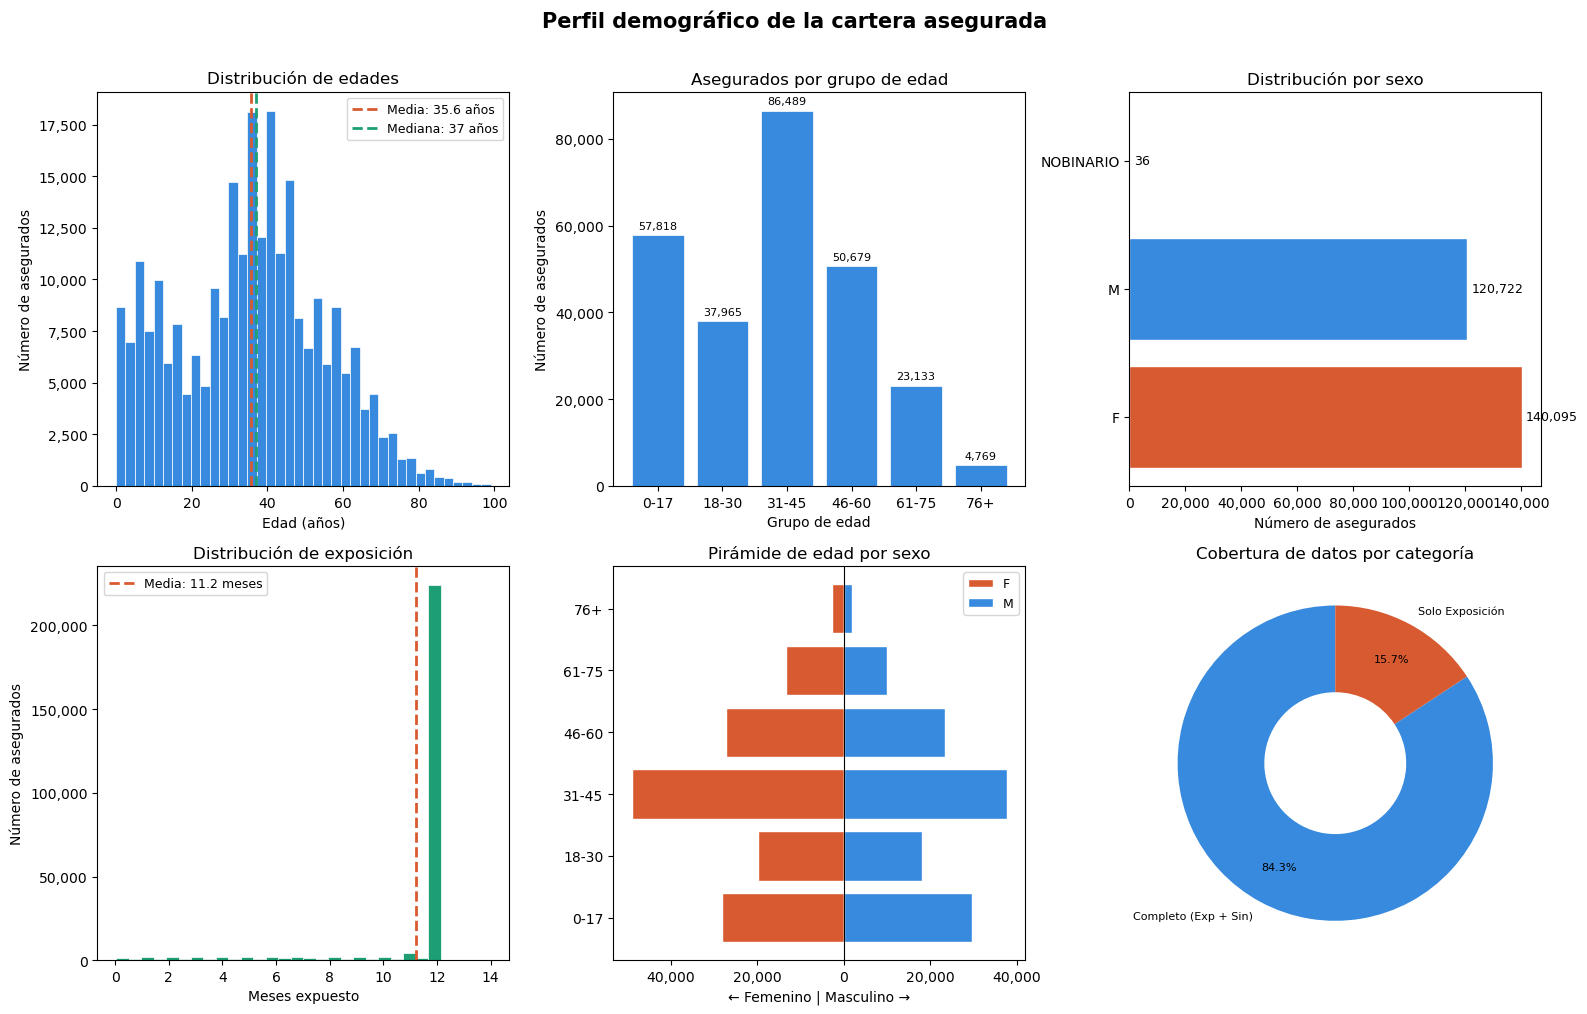

Guardado: eda_01_perfil_demografico.png


In [16]:
# ── PERFIL DEMOGRÁFICO DE LOS AFILIADOS ────────────────────────────────────────────────────────
fig, axes = plt.subplots(2, 3, figsize=(16, 10))
fig.suptitle('Perfil demográfico de la cartera asegurada', fontsize=15, fontweight='bold', y=1.01)

AZUL   = '#378ADD'
CORAL  = '#D85A30'
TEAL   = '#1D9E75'
MORADO = '#7F77DD'

# 1. Distribución de edades (histograma)
ax = axes[0, 0]
ax.hist(df_eda['edad'].dropna(), bins=40, color=AZUL, edgecolor='white', linewidth=0.5)
ax.axvline(df_eda['edad'].mean(), color=CORAL, linewidth=2, linestyle='--', label=f'Media: {df_eda["edad"].mean():.1f} años')
ax.axvline(df_eda['edad'].median(), color=TEAL, linewidth=2, linestyle='--', label=f'Mediana: {df_eda["edad"].median():.0f} años')
ax.set_title('Distribución de edades')
ax.set_xlabel('Edad (años)')
ax.set_ylabel('Número de asegurados')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# 2. Asegurados por grupo de edad (barplot)
ax = axes[0, 1]
conteo_edad = df_eda['grupo_edad'].value_counts().sort_index()
bars = ax.bar(conteo_edad.index, conteo_edad.values, color=AZUL, edgecolor='white', linewidth=0.5)
ax.bar_label(bars, fmt='{:,.0f}', fontsize=8, padding=3)
ax.set_title('Asegurados por grupo de edad')
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('Número de asegurados')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# 3. Distribución por sexo (barplot horizontal)
ax = axes[0, 2]
conteo_sexo = df_eda['Sexo_Cd_limpio'].value_counts()
colores_sexo = [CORAL if x == 'F' else AZUL if x == 'M' else MORADO for x in conteo_sexo.index]
bars = ax.barh(conteo_sexo.index, conteo_sexo.values, color=colores_sexo, edgecolor='white')
ax.bar_label(bars, fmt='{:,.0f}', padding=3, fontsize=9)
ax.set_title('Distribución por sexo')
ax.set_xlabel('Número de asegurados')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# 4. Distribución de exposición en meses (histograma)
ax = axes[1, 0]
ax.hist(df_eda['meses_expuesto_total'].clip(0, 14), bins=30, color=TEAL, edgecolor='white', linewidth=0.5)
ax.axvline(df_eda['meses_expuesto_total'].mean(), color=CORAL, linewidth=2, linestyle='--',
           label=f'Media: {df_eda["meses_expuesto_total"].mean():.1f} meses')
ax.set_title('Distribución de exposición')
ax.set_xlabel('Meses expuesto')
ax.set_ylabel('Número de asegurados')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# 5. Pirámide de edad por sexo
ax = axes[1, 1]
df_piramide = df_eda.groupby(['grupo_edad', 'Sexo_Cd_limpio']).size().unstack(fill_value=0)
if 'F' in df_piramide.columns and 'M' in df_piramide.columns:
    grupos = df_piramide.index.tolist()
    ax.barh(grupos, -df_piramide['F'], color=CORAL, label='F', edgecolor='white')
    ax.barh(grupos, df_piramide['M'], color=AZUL, label='M', edgecolor='white')
    ax.set_title('Pirámide de edad por sexo')
    ax.set_xlabel('← Femenino | Masculino →')
    ax.axvline(0, color='black', linewidth=0.8)
    vals = ax.get_xticks()
    ax.set_xticklabels([f'{abs(v):,.0f}' for v in vals])
    ax.legend(fontsize=9)

# 6. Categoría de cobertura (donut chart)
ax = axes[1, 2]
cat_cob = df_eda['categoria_cobertura'].value_counts()
colores_cob = [AZUL, CORAL, MORADO, TEAL]
wedges, texts, autotexts = ax.pie(
    cat_cob.values,
    labels=cat_cob.index,
    autopct='%1.1f%%',
    colors=colores_cob[:len(cat_cob)],
    startangle=90,
    pctdistance=0.75,
    wedgeprops=dict(width=0.55)
 )
for t in texts:
    t.set_fontsize(8)
for at in autotexts:
    at.set_fontsize(8)
ax.set_title('Cobertura de datos por categoría')

plt.tight_layout()
plt.savefig('eda_01_perfil_demografico.png', bbox_inches='tight', dpi=150)
plt.show()
print('Guardado: eda_01_perfil_demografico.png')

## ¿Quién usa el seguro?

Profe importante para la interpretación grafica (Tasa de uso por condiciones preexistentes) entender que se lee " Del 100% de las personas que dijeron tener x cantidad de condiciones preexistentes y% uso el seguro entonces su relación inversa seria  (1-x) No lo uso"


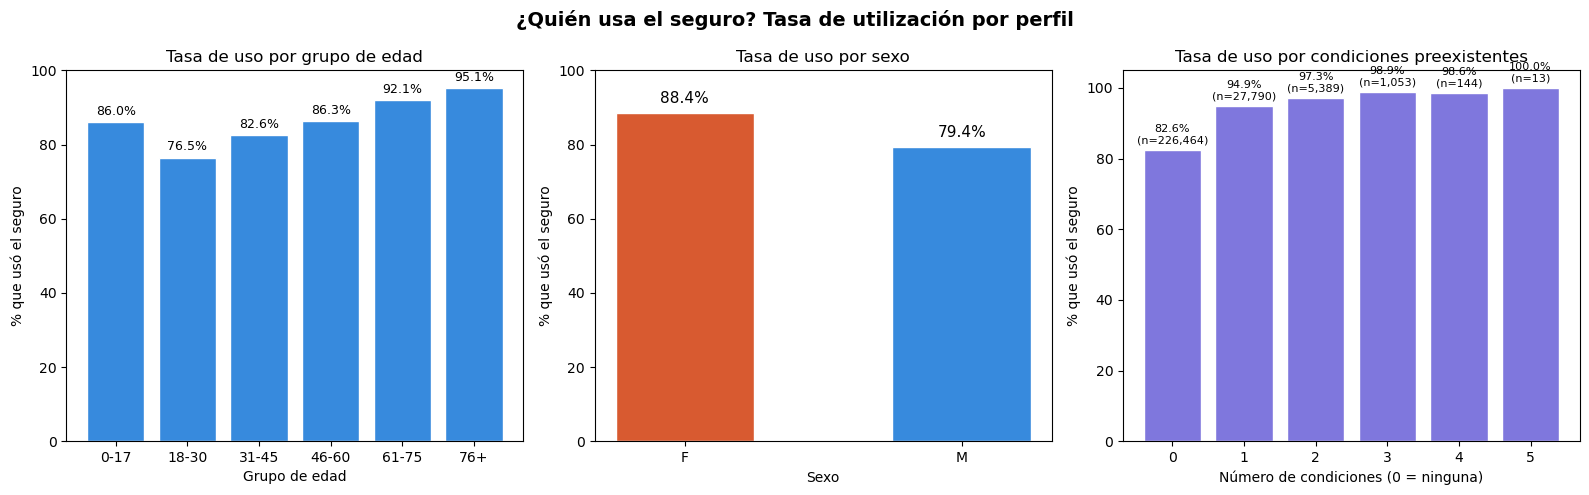

In [17]:
# ── TASA DE USO POR PERFIL ────────────────────────────────────────────────────
df_eda['uso_seguro'] = df_eda['n_reclamaciones'].fillna(0).gt(0).map({True: 'Usó el seguro', False: 'No usó el seguro'})

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('¿Quién usa el seguro? Tasa de utilización por perfil', fontsize=14, fontweight='bold')

# 1. Tasa de uso por grupo de edad
ax = axes[0]
tasa_edad = (
    df_eda.groupby('grupo_edad', observed=True)['uso_seguro']
    .apply(lambda x: (x == 'Usó el seguro').mean() * 100)
    .reset_index(name='tasa_uso_pct')
)
bars = ax.bar(tasa_edad['grupo_edad'], tasa_edad['tasa_uso_pct'],
              color=AZUL, edgecolor='white')
ax.bar_label(bars, fmt='{:.1f}%', fontsize=9, padding=3)
ax.set_title('Tasa de uso por grupo de edad')
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('% que usó el seguro')
ax.set_ylim(0, 100)

# 2. Tasa de uso por sexo
ax = axes[1]
tasa_sexo = (
    df_eda[df_eda['Sexo_Cd_limpio'].isin(['F', 'M'])]
    .groupby('Sexo_Cd_limpio')['uso_seguro']
    .apply(lambda x: (x == 'Usó el seguro').mean() * 100)
    .reset_index(name='tasa_uso_pct')
)
colores = [CORAL if s == 'F' else AZUL for s in tasa_sexo['Sexo_Cd_limpio']]
bars = ax.bar(tasa_sexo['Sexo_Cd_limpio'], tasa_sexo['tasa_uso_pct'],
              color=colores, edgecolor='white', width=0.5)
ax.bar_label(bars, fmt='{:.1f}%', fontsize=11, padding=5)
ax.set_title('Tasa de uso por sexo')
ax.set_xlabel('Sexo')
ax.set_ylabel('% que usó el seguro')
ax.set_ylim(0, 100)

# 3. Tasa de uso por número de condiciones preexistentes (con n por grupo)
ax = axes[2]
tasa_cond = (
    df_eda.groupby('num_condiciones', observed=True)['uso_seguro']
    .agg(
        n_afiliados='size',
        tasa_uso_pct=lambda x: (x == 'Usó el seguro').mean() * 100
    )
    .reset_index()
    .sort_values('num_condiciones')
)
bars = ax.bar(tasa_cond['num_condiciones'].astype(str), tasa_cond['tasa_uso_pct'],
              color=MORADO, edgecolor='white')
labels = [f"{p:.1f}%\n(n={n:,})" for p, n in zip(tasa_cond['tasa_uso_pct'], tasa_cond['n_afiliados'])]
ax.bar_label(bars, labels=labels, fontsize=8, padding=3)
ax.set_title('Tasa de uso por condiciones preexistentes')
ax.set_xlabel('Número de condiciones (0 = ninguna)')
ax.set_ylabel('% que usó el seguro')
ax.set_ylim(0, 105)

plt.tight_layout()
plt.savefig('eda_02_tasa_utilizacion.png', bbox_inches='tight', dpi=150)
plt.show()

## Sección 4: Distribución del Costo

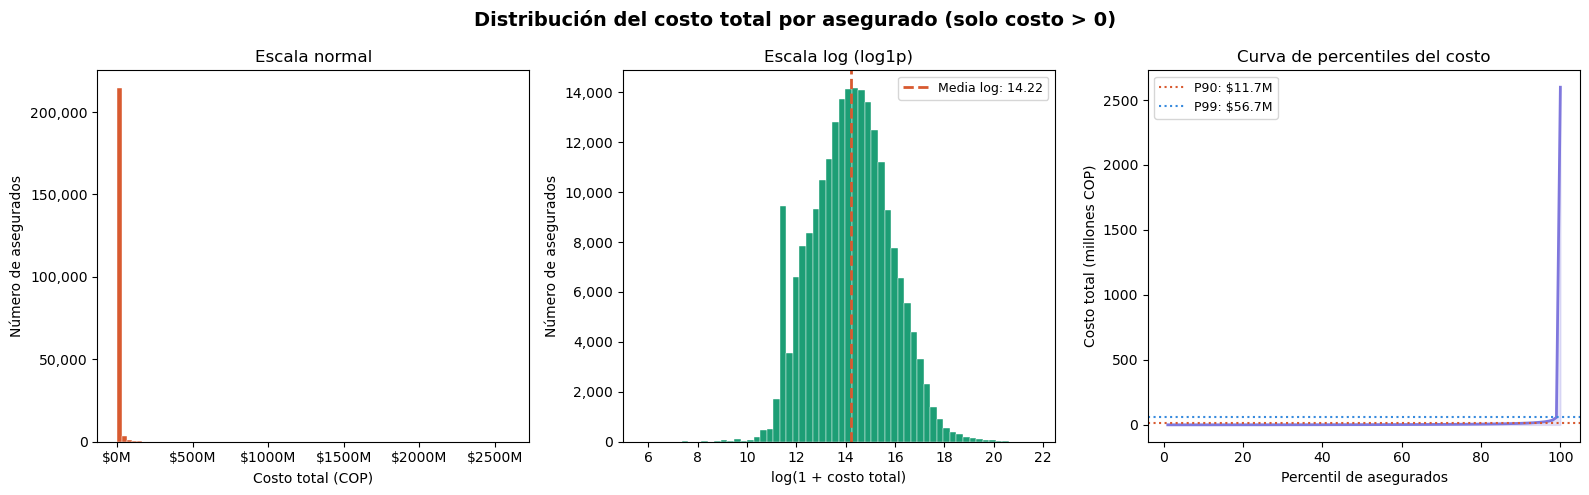


=== Cobertura de costo en la cartera ===
Total asegurados: 260,853
Sin costo (total_pagado = 0): 41,053 (15.7%)
Con costo (total_pagado > 0): 219,800 (84.3%)

=== Percentiles clave del costo (quienes reclamaron) ===
  Percentil  25: $        486,463
  Percentil  50: $      1,512,496
  Percentil  75: $      4,410,960
  Percentil  90: $     11,717,115
  Percentil  95: $     20,239,760
  Percentil  99: $     56,674,465


In [20]:
# ── DISTRIBUCIÓN DE COSTOS ────────────────────────────────────────────────────
import numpy as np

total_asegurados = len(df_eda)
n_con_costo = (df_eda['total_pagado'] > 0).sum()
n_sin_costo = total_asegurados - n_con_costo
pct_sin_costo = n_sin_costo / total_asegurados * 100

# Solo asegurados con costo > 0 para analizar severidad
df_con_costo = df_eda[df_eda['total_pagado'] > 0].copy()
df_con_costo['log_costo'] = np.log1p(df_con_costo['total_pagado'])

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
fig.suptitle('Distribución del costo total por asegurado (solo costo > 0)', fontsize=14, fontweight='bold')

# 1. Distribución en escala normal
ax = axes[0]
ax.hist(df_con_costo['total_pagado'], bins=80, color=CORAL, edgecolor='white', linewidth=0.3)
ax.set_title('Escala normal')
ax.set_xlabel('Costo total (COP)')
ax.set_ylabel('Número de asegurados')
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'${x/1e6:.0f}M'))
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# 2. Distribución en escala logarítmica
ax = axes[1]
ax.hist(df_con_costo['log_costo'], bins=60, color=TEAL, edgecolor='white', linewidth=0.3)
ax.axvline(
    df_con_costo['log_costo'].mean(),
    color=CORAL, linewidth=2, linestyle='--',
    label=f'Media log: {df_con_costo["log_costo"].mean():.2f}'
)
ax.set_title('Escala log (log1p)')
ax.set_xlabel('log(1 + costo total)')
ax.set_ylabel('Número de asegurados')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x, _: f'{x:,.0f}'))

# 3. Curva de percentiles del costo
ax = axes[2]
percentiles = np.arange(1, 101)
valores_pct = np.percentile(df_con_costo['total_pagado'], percentiles)
ax.plot(percentiles, valores_pct / 1e6, color=MORADO, linewidth=2)
ax.fill_between(percentiles, valores_pct / 1e6, alpha=0.2, color=MORADO)
ax.set_title('Curva de percentiles del costo')
ax.set_xlabel('Percentil de asegurados')
ax.set_ylabel('Costo total (millones COP)')

# Marcar P90 y P99
p90 = np.percentile(df_con_costo['total_pagado'], 90)
p99 = np.percentile(df_con_costo['total_pagado'], 99)
ax.axhline(p90 / 1e6, color=CORAL, linestyle=':', linewidth=1.5, label=f'P90: ${p90/1e6:.1f}M')
ax.axhline(p99 / 1e6, color=AZUL, linestyle=':', linewidth=1.5, label=f'P99: ${p99/1e6:.1f}M')
ax.legend(fontsize=9)

plt.tight_layout()
plt.savefig('eda_03_distribucion_costos.png', bbox_inches='tight', dpi=150)
plt.show()

# Resumen complementario de negocio
print('\n=== Cobertura de costo en la cartera ===')
print(f'Total asegurados: {total_asegurados:,}')
print(f'Sin costo (total_pagado = 0): {n_sin_costo:,} ({pct_sin_costo:.1f}%)')
print(f'Con costo (total_pagado > 0): {n_con_costo:,} ({100 - pct_sin_costo:.1f}%)')

print('\n=== Percentiles clave del costo (quienes reclamaron) ===')
for p in [25, 50, 75, 90, 95, 99]:
    val = np.percentile(df_con_costo['total_pagado'], p)
    print(f'  Percentil {p:3d}: ${val:>15,.0f}')

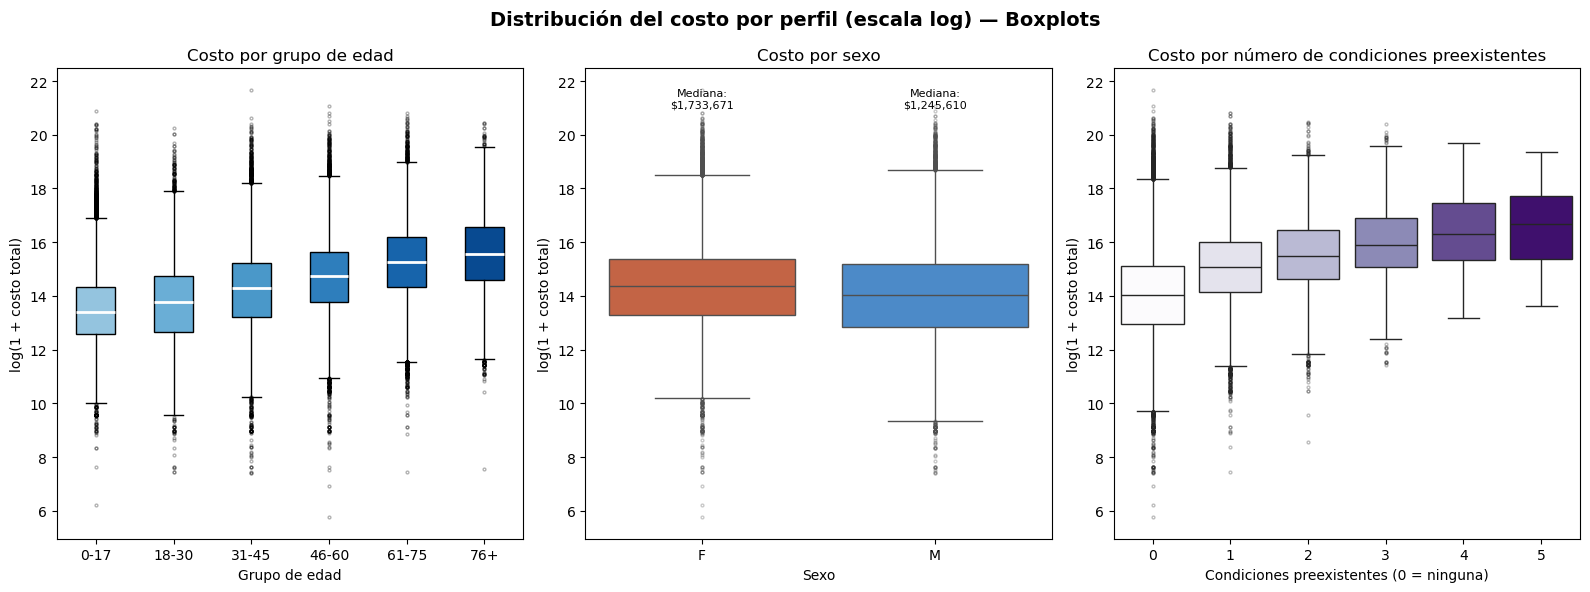

Guardado: eda_04_boxplots_costo_perfil.png


In [ ]:
# ─BOXPLOTS: COSTO POR PERFIL ────────────────────────────────────────────────
import seaborn as sns

# Si la celda anterior no se ha corrido, construimos df_con_costo aquí también
if 'df_con_costo' not in globals():
    df_con_costo = df_eda[df_eda['total_pagado'] > 0].copy()
    df_con_costo['log_costo'] = np.log1p(df_con_costo['total_pagado'])

# Usamos escala log para que los grupos pequeños y los costos bajos también sean visibles
df_box = df_con_costo.copy()

fig, axes = plt.subplots(1, 3, figsize=(16, 6))
fig.suptitle('Distribución del costo por perfil (escala log) — Boxplots', fontsize=14, fontweight='bold')

# 1. Costo por grupo de edad
ax = axes[0]
grupos_orden = ['0-17', '18-30', '31-45', '46-60', '61-75', '76+']
data_edad = [df_box[df_box['grupo_edad'] == g]['log_costo'].dropna().values for g in grupos_orden]
bp = ax.boxplot(
    data_edad,
    tick_labels=grupos_orden,
    patch_artist=True,
    medianprops=dict(color='white', linewidth=2),
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
 )
for patch, color in zip(bp['boxes'], plt.cm.Blues(np.linspace(0.4, 0.9, len(grupos_orden)))):
    patch.set_facecolor(color)
ax.set_title('Costo por grupo de edad')
ax.set_xlabel('Grupo de edad')
ax.set_ylabel('log(1 + costo total)')

# 2. Costo por sexo
ax = axes[1]
df_sexo_box = df_box[df_box['Sexo_Cd_limpio'].isin(['F', 'M'])]
sns.boxplot(
    data=df_sexo_box,
    x='Sexo_Cd_limpio',
    y='log_costo',
    hue='Sexo_Cd_limpio',
    palette={'F': CORAL, 'M': AZUL},
    legend=False,
    ax=ax,
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
 )
ax.set_title('Costo por sexo')
ax.set_xlabel('Sexo')
ax.set_ylabel('log(1 + costo total)')

y_top = df_sexo_box['log_costo'].max() * 0.97
for i, sexo in enumerate(['F', 'M']):
    med = df_sexo_box[df_sexo_box['Sexo_Cd_limpio'] == sexo]['total_pagado'].median()
    ax.text(i, y_top, f'Mediana:\n${med:,.0f}', ha='center', fontsize=8, color='black')

# 3. Costo por número de condiciones preexistentes
ax = axes[2]
sns.boxplot(
    data=df_box,
    x='num_condiciones',
    y='log_costo',
    hue='num_condiciones',
    palette='Purples',
    legend=False,
    ax=ax,
    flierprops=dict(marker='o', markersize=2, alpha=0.3)
 )
ax.set_title('Costo por número de condiciones preexistentes')
ax.set_xlabel('Condiciones preexistentes (0 = ninguna)')
ax.set_ylabel('log(1 + costo total)')

plt.tight_layout()
plt.savefig('eda_04_boxplots_costo_perfil.png', bbox_inches='tight', dpi=150)
plt.show()

print('Guardado: eda_04_boxplots_costo_perfil.png')